# Классификация эффекторных белков (T6SE): сравнение моделей и ансамбль

Цель: по извлеченным признакам последовательностей белка построить и сравнить несколько нелинейных моделей для бинарной классификации (`эффектор` / `не эффектор`), затем собрать ансамбль.

В ноутбуке показаны обязательные этапы:
1. Загрузка данных и отбор признаков.
2. Построение моделей и описание используемых подходов.
3. Обучение и оценка качества с корректной методологией.

## Зависимости и воспроизводимость

Ноутбук использует `scikit-learn`, `pandas`, `numpy`, `matplotlib`, `seaborn`.

Если пакеты не установлены:
```bash
pip install -e .
pip install scikit-learn matplotlib seaborn
```

Для воспроизводимости фиксируем `random_state=42`.

In [16]:
from pathlib import Path
from datetime import datetime, timezone
import json
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.feature_selection import SelectPercentile, f_classif
from sklearn.feature_selection import VarianceThreshold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

## Загрузка данных и первичная проверка

Используем таблицу признаков, собранную на предыдущем этапе: `out/all_features.csv`.

Ожидаемые столбцы:
- `id` — идентификатор последовательности;
- `label` — целевой класс (`1` — эффектор, `0` — не эффектор);
- остальные столбцы — численные признаки AAC/DPC/QSO/CTD.

In [2]:
DATA_CANDIDATES = [
    Path("../out/all_features.csv"),
    Path("../data/all_features.csv"),
]

for candidate in DATA_CANDIDATES:
    if candidate.exists():
        data_path = candidate
        break
else:
    raise FileNotFoundError(
        "Не найден файл признаков. Ожидался out/all_features.csv или data/all_features.csv"
    )

print(f"Используется файл: {data_path}")

df = pd.read_csv(data_path)
print(f"Размер таблицы: {df.shape}")
print(df[["id", "label"]].head())

Используется файл: ../out/all_features.csv
Размер таблицы: (1250, 564)
                                         id  label
0  gi|77358963|ref|YP_338391.1|hypothetical      1
1     gi|9948776|gb|AAG06090.1|hypothetical      1
2       gi|32261790|gb|AAP76840.1|conserved      1
3         gi|49080696|gb|AAT50048.1|PA0085,      1
4    gi|32261789|gb|AAP76839.1|hypothetical      1


In [3]:
# Базовая диагностика качества данных
print("Типы данных:")
print(df.dtypes.head(10))

print("Пропуски (топ-10):")
missing = df.isna().sum().sort_values(ascending=False)
print(missing.head(10))

print("Баланс классов:")
class_counts = df["label"].value_counts().sort_index()
print(class_counts)
print("Доли классов:")
print((class_counts / class_counts.sum()).round(4))

Типы данных:
id           str
label      int64
AAC_A    float64
AAC_C    float64
AAC_D    float64
AAC_E    float64
AAC_F    float64
AAC_G    float64
AAC_H    float64
AAC_I    float64
dtype: object
Пропуски (топ-10):
id       0
label    0
AAC_A    0
AAC_C    0
AAC_D    0
AAC_E    0
AAC_F    0
AAC_G    0
AAC_H    0
AAC_I    0
dtype: int64
Баланс классов:
label
0    1112
1     138
Name: count, dtype: int64
Доли классов:
label
0    0.8896
1    0.1104
Name: count, dtype: float64


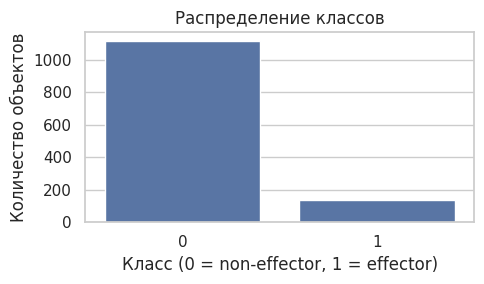

In [4]:
# Визуализация дисбаланса классов
plt.figure(figsize=(5, 3))
ax = sns.countplot(data=df, x="label")
ax.set_title("Распределение классов")
ax.set_xlabel("Класс (0 = non-effector, 1 = effector)")
ax.set_ylabel("Количество объектов")
plt.tight_layout()
plt.show()

## 1.1) Подготовка признаков: принцип и обоснование

Исходные признаки (из прошлого этапа) объединяют несколько семейств дескрипторов белковой последовательности:
- `AAC` (Amino Acid Composition): доли 20 аминокислот в последовательности.
- `DPC` (Dipeptide Composition): частоты пар аминокислот (учет локального порядка).
- `QSO` (Quasi-Sequence-Order): квазипорядковые дескрипторы, связывающие состав и порядок остатков.
- `CTD` (Composition/Transition/Distribution): агрегаты по физико-химическим группам аминокислот.

Почему нужна дополнительная подготовка:
1. Признаков много, часть из них может быть почти постоянной или слабоинформативной.
2. Для SVM/MLP критичен масштаб признаков, иначе модель может смещаться к признакам с большими численными диапазонами.
3. На дисбалансном датасете важно не переобучаться на шумовые признаки.

Используемый пайплайн подготовки:
1. Убираем служебные столбцы (`id`, `label`) из матрицы `X`.
2. `VarianceThreshold(threshold=0.0)`:
- удаляет признаки с нулевой дисперсией (константы);
- такие признаки не разделяют классы и только увеличивают размерность.
3. `SelectPercentile(score_func=f_classif, percentile=...)`:
- для каждого признака считает ANOVA F-статистику (отношение межклассовой и внутриклассовой вариации);
- чем выше F-score, тем сильнее признак связан с целевым классом;
- оставляем верхний процент признаков (фильтрационный отбор).
4. `StandardScaler()` (для SVM/MLP):
- центрирует признаки (среднее 0) и нормирует к единичному стандартному отклонению;
- стабилизирует оптимизацию и делает вклад признаков сопоставимым.

Почему все шаги внутри `Pipeline`:
- при кросс-валидации отбор и масштабирование считаются только на train-fold;
- это исключает leakage (утечку информации из validation/test в обучение);
- метрики получаются более честными и переносимыми на новые данные.


### Интерпретация отбора признаков

Фильтрационный метод (`SelectPercentile`) оценивает признаки независимо друг от друга.
Это быстро и устойчиво на высоких размерностях, но может не учитывать взаимодействия между признаками.
Поэтому далее сравниваются разные модели:
- `SVM` и `MLP` лучше используют сложные нелинейные комбинации признаков;
- `RandomForest` частично компенсирует ограничение фильтрационного отбора за счет деревьев и ансамблирования.


In [5]:
# Матрица признаков и вектор цели
X = df.drop(columns=["id", "label"]).copy()
y = df["label"].astype(int).copy()

# Для безопасности заполним возможные NaN нулями (для этого датасета обычно не требуется)
X = X.fillna(0.0)

print("Форма X:", X.shape)
print("Форма y:", y.shape)

Форма X: (1250, 562)
Форма y: (1250,)


In [6]:
# Стратифицированное разбиение train/test (hold-out)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("Train:", X_train.shape, y_train.value_counts().to_dict())
print("Test :", X_test.shape, y_test.value_counts().to_dict())

Train: (1000, 562) {0: 890, 1: 110}
Test : (250, 562) {0: 222, 1: 28}


## 2) Построение моделей

Сравниваем три нелинейных подхода:
- `SVM (RBF)` — хорошо работает в задачах с нелинейной границей, чувствителен к масштабированию.
- `Random Forest` — ансамбль деревьев, устойчив к шуму и нелинейностям.
- `MLP` — полносвязная нейросеть для сложных зависимостей.

Отдельно строим итоговый ансамбль `VotingClassifier (soft voting)` поверх этих моделей.

In [7]:
variance_filter = VarianceThreshold(threshold=0.0)
selector = SelectPercentile(score_func=f_classif, percentile=35)

models = {
    "SVM_RBF": Pipeline(
        steps=[
            ("var", variance_filter),
            ("select", selector),
            ("scale", StandardScaler()),
            (
                "clf",
                SVC(
                    kernel="rbf",
                    C=2.0,
                    gamma="scale",
                    probability=True,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "RandomForest": Pipeline(
        steps=[
            ("var", variance_filter),
            ("select", selector),
            (
                "clf",
                RandomForestClassifier(
                    n_estimators=500,
                    max_depth=None,
                    min_samples_leaf=1,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
    "MLP": Pipeline(
        steps=[
            ("var", variance_filter),
            ("select", selector),
            ("scale", StandardScaler()),
            (
                "clf",
                MLPClassifier(
                    hidden_layer_sizes=(256, 64),
                    activation="relu",
                    alpha=1e-4,
                    learning_rate_init=1e-3,
                    max_iter=600,
                    early_stopping=True,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
}

list(models.keys())

['SVM_RBF', 'RandomForest', 'MLP']

## Обучение и оценка качества

Методология:
1. На тренировочной части проводим стратифицированную 5-fold кросс-валидацию.
2. Основные метрики: `F1`, `ROC-AUC`, `PR-AUC`, `balanced accuracy`.
3. После выбора моделей обучаем на всем `train` и проверяем на отложенном `test`.

Почему так:
- дисбаланс классов делает `accuracy` недостаточной;
- `PR-AUC` и `F1` лучше отражают качество по редкому положительному классу.

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "bal_acc": "balanced_accuracy",
}

cv_rows = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False,
    )
    row = {"model": name}
    for metric in scoring:
        row[f"cv_{metric}_mean"] = float(np.mean(scores[f"test_{metric}"]))
        row[f"cv_{metric}_std"] = float(np.std(scores[f"test_{metric}"]))
    cv_rows.append(row)

cv_results = pd.DataFrame(cv_rows).sort_values("cv_f1_mean", ascending=False)
cv_results

,model,cv_f1_mean,cv_f1_std,cv_roc_auc_mean,cv_roc_auc_std,cv_pr_auc_mean,cv_pr_auc_std,cv_bal_acc_mean,cv_bal_acc_std
0,SVM_RBF,0.597389,0.117304,0.923136,0.019228,0.681266,0.075922,0.751277,0.081365
2,MLP,0.582189,0.084894,0.899030,0.027993,0.691671,0.030329,0.728498,0.051166
1,RandomForest,0.366500,0.137266,0.933146,0.014434,0.752351,0.087546,0.617058,0.053214


In [9]:
def evaluate_on_test(model, X_test, y_test, name: str):
    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        # fallback для моделей без predict_proba
        y_prob = y_pred.astype(float)

    return {
        "model": name,
        "test_accuracy": accuracy_score(y_test, y_pred),
        "test_bal_acc": balanced_accuracy_score(y_test, y_pred),
        "test_f1": f1_score(y_test, y_pred),
        "test_roc_auc": roc_auc_score(y_test, y_prob),
        "test_pr_auc": average_precision_score(y_test, y_prob),
        "y_pred": y_pred,
        "y_prob": y_prob,
    }


test_rows = []
fitted_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model
    test_rows.append(evaluate_on_test(model, X_test, y_test, name))

# Метрики в таблицу (без служебных полей)
test_metrics = pd.DataFrame(
    [{k: v for k, v in row.items() if k not in {"y_pred", "y_prob"}} for row in test_rows]
).sort_values("test_f1", ascending=False)

print("Качество на test:")
display(test_metrics)

Качество на test:


,model,test_accuracy,test_bal_acc,test_f1,test_roc_auc,test_pr_auc
0,SVM_RBF,0.940,0.810167,0.705882,0.969434,0.791437
2,MLP,0.928,0.740991,0.608696,0.966216,0.778638
1,RandomForest,0.912,0.653958,0.450000,0.979891,0.819756


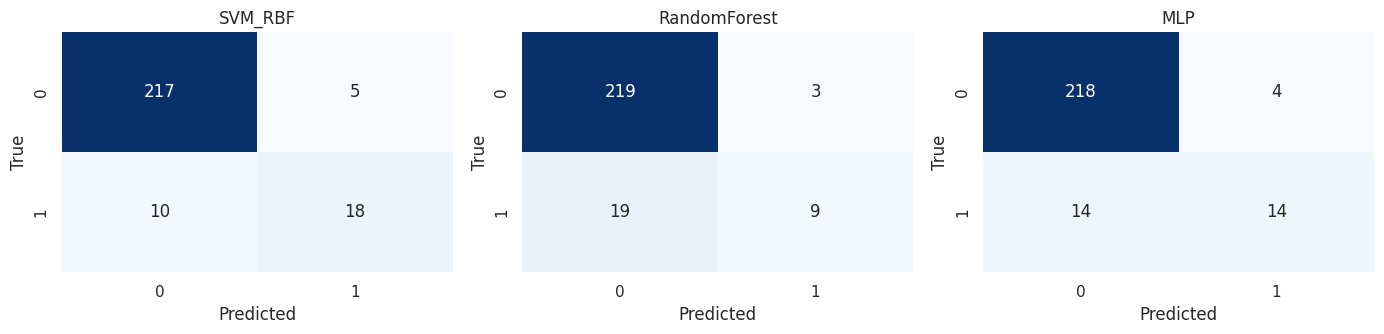

In [10]:
# Матрицы ошибок для базовых моделей
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, row in zip(axes, test_rows):
    cm = confusion_matrix(y_test, row["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(row["model"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
plt.show()

In [11]:
all_test_metrics = pd.concat(
    [
        test_metrics,
    ],
    ignore_index=True,
).sort_values("test_f1", ascending=False)

display(all_test_metrics)

best_name = all_test_metrics.iloc[0]["model"]
print(f"Лучшая модель по test F1: {best_name}")

,model,test_accuracy,test_bal_acc,test_f1,test_roc_auc,test_pr_auc
0,SVM_RBF,0.940,0.810167,0.705882,0.969434,0.791437
1,MLP,0.928,0.740991,0.608696,0.966216,0.778638
2,RandomForest,0.912,0.653958,0.450000,0.979891,0.819756


Лучшая модель по test F1: SVM_RBF


## 3.2) Подбор гиперпараметров через GridSearchCV 

Чтобы сократить время, выполняем `GridSearchCV` только для одной модели: `SVM_RBF`.
Оптимизация идет по метрике `F1` на тренировочной выборке.


In [12]:
svm_param_grid = {
    "select__percentile": [25, 35, 50],
    "clf__C": [0.5, 1.0, 2.0, 4.0],
    "clf__gamma": ["scale", 0.01, 0.1],
}

cv_gs = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("GridSearch for SVM_RBF ...")
svm_gs = GridSearchCV(
    estimator=models["SVM_RBF"],
    param_grid=svm_param_grid,
    scoring="f1",
    cv=cv_gs,
    n_jobs=-1,
    refit=True,
    verbose=1,
)
svm_gs.fit(X_train, y_train)

svm_tuned = svm_gs.best_estimator_

grid_summary = pd.DataFrame([{
    "model": "SVM_RBF_tuned",
    "best_cv_f1": svm_gs.best_score_,
    "best_params": svm_gs.best_params_,
}])

grid_summary


GridSearch for SVM_RBF ...
Fitting 5 folds for each of 36 candidates, totalling 180 fits


,model,best_cv_f1,best_params
0,SVM_RBF_tuned,0.63778,"{'clf__C': 1.0, 'clf__gamma': 'scale', 'select..."


### Оценка tuned SVM_RBF

Проверяем качество лучшей найденной конфигурации `SVM_RBF` на отложенном `test`.


In [13]:
svm_tuned_result = evaluate_on_test(svm_tuned, X_test, y_test, "SVM_RBF_tuned")
svm_tuned_metrics = pd.DataFrame([
    {k: v for k, v in svm_tuned_result.items() if k not in {"y_pred", "y_prob"}}
])

display(svm_tuned_metrics)


,model,test_accuracy,test_bal_acc,test_f1,test_roc_auc,test_pr_auc
0,SVM_RBF_tuned,0.948,0.877091,0.77193,0.97603,0.72847


### Сравнение baseline и tuned

Сравниваем исходные модели из baseline-блока и `SVM_RBF` после подбора параметров.


In [14]:
final_compare = pd.concat(
    [
        all_test_metrics.assign(stage="baseline"),
        svm_tuned_metrics.assign(stage="gridsearch"),
    ],
    ignore_index=True,
).sort_values("test_f1", ascending=False)

display(final_compare)
print("Лучшая модель после упрощенного GridSearch:", final_compare.iloc[0]["model"])


,model,test_accuracy,test_bal_acc,test_f1,test_roc_auc,test_pr_auc,stage
3,SVM_RBF_tuned,0.948,0.877091,0.771930,0.976030,0.728470,gridsearch
0,SVM_RBF,0.940,0.810167,0.705882,0.969434,0.791437,baseline
1,MLP,0.928,0.740991,0.608696,0.966216,0.778638,baseline
2,RandomForest,0.912,0.653958,0.450000,0.979891,0.819756,baseline


Лучшая модель после упрощенного GridSearch: SVM_RBF_tuned


## 4) Сохранение модели для следующего задания

Сохраняем лучшую модель из `final_compare` в формате `pickle`. Важно: сохраняется весь `Pipeline` (отбор признаков + масштабирование + классификатор), поэтому при загрузке можно подавать сырые признаки в том же формате.


In [17]:
artifacts_dir = Path("models")
artifacts_dir.mkdir(parents=True, exist_ok=True)

best_row = final_compare.iloc[0]
best_model_name = best_row["model"]

if best_model_name == "SVM_RBF_tuned":
    best_model_obj = svm_tuned
else:
    # baseline модель из словаря fitted_models
    best_model_obj = fitted_models[best_model_name]

model_path = artifacts_dir / "t6se_best_model.pkl"
with open(model_path, "wb") as f:
    pickle.dump(best_model_obj, f)

metrics_payload = {k: float(best_row[k]) if isinstance(best_row[k], (int, float)) else str(best_row[k]) for k in final_compare.columns}
metadata = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "model_name": best_model_name,
    "source_features_file": str(data_path),
    "n_samples": int(X.shape[0]),
    "n_features": int(X.shape[1]),
    "feature_columns": X.columns.tolist(),
    "selection_criterion": "max_test_f1",
    "best_row": metrics_payload,
}

metadata_path = artifacts_dir / "t6se_best_model_metadata.json"
metadata_path.write_text(json.dumps(metadata, ensure_ascii=False, indent=2), encoding="utf-8")

print("Saved model:", model_path)
print("Saved metadata:", metadata_path)


Saved model: models/t6se_best_model.pkl
Saved metadata: models/t6se_best_model_metadata.json
